In [1]:
#Building GANs

In [2]:
import os
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [3]:
art1=pd.read_csv("art.csv")

In [4]:
art1.sample(5)

,Unnamed: 0,painting,art_style,emotion,utterance,repetition,artpath
2089,61187,pierre-auguste-renoir_landscape-with-bridge,Impressionism,disgusted,This painting makes me feel uneasy because the...,5,C:\Users\manas\Downloads\wikiart\Impressionism...
175,73746,victor-borisov-musatov_a-caucasian-study-1895,Impressionism,happy,Brush strokes are horizontal suggesting quick ...,6,C:\Users\manas\Downloads\wikiart\Impressionism...
464,16167,edgar-degas_portrait-of-lorenzo-pagans-spanish...,Impressionism,happy,The guitar is so wonderfully realistic and I c...,5,C:\Users\manas\Downloads\wikiart\Impressionism...
2303,21062,filippo-lippi_female-figure-1430,Early_Renaissance,angry,the way she is looking down and holding her ha...,5,C:\Users\manas\Downloads\wikiart\Early_Renaiss...
1615,75682,vincent-van-gogh_tree-with-ivy-in-the-asylum-g...,Post_Impressionism,disgusted,There is too much going on in this picture and...,5,C:\Users\manas\Downloads\wikiart\Post_Impressi...


In [5]:
image_gen = ImageDataGenerator(rescale=1/255.0)
lbl_enc = LabelEncoder()
enc_lbls = lbl_enc.fit_transform(art1['emotion'])
one_hot_lbls = to_categorical(enc_lbls)

In [6]:
def ld_imgs(paths, lbls, batch_size=32):
    return image_gen.flow_from_dataframe(
        dataframe=pd.DataFrame({'file_path': paths, 'label': lbls}),
        x_col='file_path',
        y_col='label',
        target_size=(64, 64),
        class_mode='categorical',
        batch_size=batch_size
    )

In [7]:
str_lbls = [str(lbl) for lbl in enc_lbls]
train_gen = ld_imgs(art1['artpath'], str_lbls)
batch_imgs, batch_lbls = next(train_gen)

Found 2485 validated image filenames belonging to 7 classes.


In [8]:
emotion_dict = {i: emotion for i, emotion in enumerate(lbl_enc.classes_)}
emotion_dict

{0: 'angry',
 1: 'disgusted',
 2: 'fearful',
 3: 'happy',
 4: 'neutral',
 5: 'sad',
 6: 'surprised'}

In [9]:
train_gen

In [10]:
train_paths, val_paths, train_lbls, val_lbls = train_test_split(
    art1['artpath'].values, enc_lbls, test_size=0.08, random_state=512
)

In [11]:
def ld_img(file_path, lbl):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [64, 64])
    img = (img - 127.5) / 127.5
    return img, lbl

def crt_ds(paths, lbls, batch_size=32, shuf=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, lbls))
    ds = ds.map(ld_img, num_parallel_calls=tf.data.AUTOTUNE)
    if shuf:
        ds = ds.shuffle(10000)
    ds = ds.batch(batch_size, drop_remainder=True)
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds

In [12]:
train_ds = crt_ds(train_paths, train_lbls, batch_size=16)
val_ds = crt_ds(val_paths, val_lbls, batch_size=16)

In [13]:
def plt_imgs(ds, lbl_enc, num_imgs=5):
    first_batch = next(iter(ds))
    imgs, lbls = first_batch
    fig, axs = plt.subplots(1, num_imgs, figsize=(15, 5))
    for i, (img, lbl) in enumerate(zip(imgs[:num_imgs], lbls[:num_imgs])):
        dec_lbl = lbl_enc.inverse_transform([lbl.numpy()])
        img = (img.numpy() + 1) / 2
        axs[i].imshow(img)
        axs[i].set_title(f"Lbl: {dec_lbl[0]}")
        axs[i].axis('off')
    plt.show()

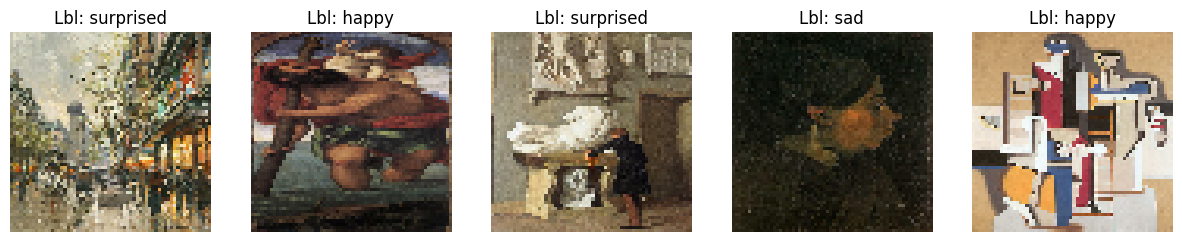

In [14]:
plt_imgs(train_ds, lbl_enc, num_imgs=5)

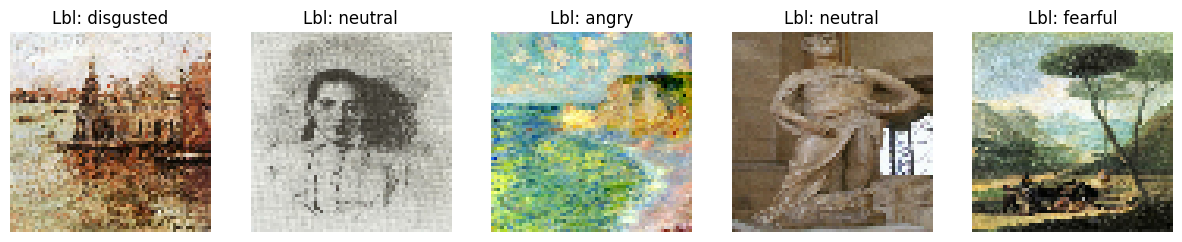

In [15]:
plt_imgs(val_ds, lbl_enc, num_imgs=5)

In [19]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(16, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(16,), dtype=tf.int32, name=None))>

In [20]:
val_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(16, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(16,), dtype=tf.int32, name=None))>

In [21]:
train_ds = train_ds.map(lambda image, label: (image, label))

In [22]:
train_ds

<_MapDataset element_spec=(TensorSpec(shape=(16, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(16,), dtype=tf.int32, name=None))>

In [24]:
val_ds = val_ds.map(lambda image, label: (image, label))

In [25]:
val_ds

<_MapDataset element_spec=(TensorSpec(shape=(16, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(16,), dtype=tf.int32, name=None))>

In [26]:
for images, labels in train_ds.take(1):
    print(f"Images shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")

Images shape: (16, 64, 64, 3)
Labels shape: (16,)


In [41]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Reshape, Conv2D, Conv2DTranspose, LeakyReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np

In [52]:
def build_generator(z_dim, num_classes):
    # Input for random latent vector (z)
    z_input = tf.keras.Input(shape=(z_dim,))
    
    # Input for one-hot encoded label
    label_input = tf.keras.Input(shape=(num_classes,))
    
    # Concatenate z_input and label_input
    model_input = tf.concat([z_input, label_input], axis=-1)  # shape: (batch_size, z_dim + num_classes)

    x = Dense(256, activation=LeakyReLU())(model_input)
    x = Dense(512, activation=LeakyReLU())(x)
    x = Dense(1024, activation=LeakyReLU())(x)

    # Output layer for image generation
    x = Dense(64 * 64 * 3, activation='tanh')(x)  # Image shape (64, 64, 3)
    x = Reshape((64, 64, 3))(x)  # Reshape to the image dimensions

    # Return the model with two inputs
    model = tf.keras.Model([z_input, label_input], x)
    return model

In [53]:
def build_discriminator(img_shape, num_classes):
    # Input for image
    img_input = tf.keras.Input(shape=img_shape)

    # Input for one-hot encoded label
    label_input = tf.keras.Input(shape=(num_classes,))

    # Embed label into image space
    label_embedding = Dense(np.prod(img_shape))(label_input)
    label_embedding = Reshape(img_shape)(label_embedding)

    # Concatenate image and label embedding
    x = tf.concat([img_input, label_embedding], axis=-1)

    # Convolutional layers for image processing
    x = Conv2D(64, kernel_size=3, strides=2, padding='same')(x)
    x = LeakyReLU()(x)
    x = Conv2D(128, kernel_size=3, strides=2, padding='same')(x)
    x = LeakyReLU()(x)
    x = Flatten()(x)

    # Output layer for classification (real or fake)
    x = Dense(1, activation='sigmoid')(x)

    # Return the model with two inputs
    model = tf.keras.Model([img_input, label_input], x)
    return model

In [31]:
def compile_discriminator(discriminator):
    discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [32]:
def compile_gan(generator, discriminator):
    discriminator.trainable = False
    
    gan_input = layers.Input(shape=(z_dim,))
    label_input = layers.Input(shape=(num_classes,))
    
    generated_image = generator([gan_input, label_input])
    gan_output = discriminator([generated_image, label_input])
    
    cgan = models.Model([gan_input, label_input], gan_output)
    
    cgan.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return cgan

In [33]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [34]:
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

In [54]:
batch_size=16
@tf.function
def train_step(images, labels, z_dim, generator, discriminator):
    # One-hot encode labels
    labels_one_hot = tf.one_hot(labels, depth=7)
    
    # Create random latent vector z
    z = tf.random.normal([batch_size, z_dim])

    # Start the Gradient Tape for backpropagation
    with tf.GradientTape(persistent=True) as tape:
        # Generate fake images
        generated_images = generator([z, labels_one_hot], training=True)

        # Get discriminator predictions for real and fake images
        real_output = discriminator([images, labels_one_hot], training=True)
        fake_output = discriminator([generated_images, labels_one_hot], training=True)

        # Calculate loss for discriminator
        real_loss = cross_entropy(tf.ones_like(real_output), real_output)
        fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
        d_loss = real_loss + fake_loss

        # Calculate loss for generator
        g_loss = cross_entropy(tf.ones_like(fake_output), fake_output)

    # Calculate gradients and apply to the models
    d_gradients = tape.gradient(d_loss, discriminator.trainable_variables)
    g_gradients = tape.gradient(g_loss, generator.trainable_variables)

    discriminator_optimizer.apply_gradients(zip(d_gradients, discriminator.trainable_variables))
    generator_optimizer.apply_gradients(zip(g_gradients, generator.trainable_variables))

    return g_loss, d_loss

In [55]:
z_dim=100
num_classes=7
img_shape=(64,64,3)

In [42]:
generator = build_generator(z_dim, num_classes)
discriminator = build_discriminator(img_shape, num_classes)

In [65]:
def train(dataset, z_dim, generator, discriminator, epochs):
    for epoch in range(epochs):
        
        for images, labels in dataset:
            g_loss, d_loss = train_step(images, labels, z_dim, generator, discriminator)

        print(f'Epoch {epoch+1}/{epochs}, '
              f'Generator Loss: {g_loss.numpy():.4f}, '
              f'Discriminator Loss: {d_loss.numpy():.4f}')

In [66]:
import warnings
warnings.filterwarnings("ignore")

In [67]:
train(train_ds, z_dim=100, generator=generator, discriminator=discriminator, epochs=21)

Epoch 1/21, Generator Loss: 3.9754, Discriminator Loss: 0.0356
Epoch 2/21, Generator Loss: 3.5384, Discriminator Loss: 0.6790
Epoch 3/21, Generator Loss: 4.1780, Discriminator Loss: 0.1668
Epoch 4/21, Generator Loss: 4.6740, Discriminator Loss: 0.3700
Epoch 5/21, Generator Loss: 3.9226, Discriminator Loss: 0.1767
Epoch 6/21, Generator Loss: 3.3342, Discriminator Loss: 0.5469
Epoch 7/21, Generator Loss: 2.1301, Discriminator Loss: 0.7000
Epoch 8/21, Generator Loss: 2.3408, Discriminator Loss: 0.5246
Epoch 9/21, Generator Loss: 1.4404, Discriminator Loss: 0.5308
Epoch 10/21, Generator Loss: 1.5096, Discriminator Loss: 0.7885
Epoch 11/21, Generator Loss: 2.4467, Discriminator Loss: 1.2173
Epoch 12/21, Generator Loss: 1.1677, Discriminator Loss: 0.6585
Epoch 13/21, Generator Loss: 2.3285, Discriminator Loss: 0.5722
Epoch 14/21, Generator Loss: 1.1599, Discriminator Loss: 0.8018
Epoch 15/21, Generator Loss: 1.1553, Discriminator Loss: 0.8758
Epoch 16/21, Generator Loss: 0.9340, Discriminato

In [68]:
generator.save('genwiki.keras')
discriminator.save('discwiki.keras')

In [74]:
emotion_dict

{0: 'angry',
 1: 'disgusted',
 2: 'fearful',
 3: 'happy',
 4: 'neutral',
 5: 'sad',
 6: 'surprised'}

In [77]:
def vis_imgs(gen, z_dim, n_imgs=16, n_cls=7):
    noise = tf.random.normal([n_imgs, z_dim])
    lbls = tf.random.uniform([n_imgs], minval=0, maxval=n_cls, dtype=tf.int32)
    lbls_one_hot = tf.one_hot(lbls, depth=n_cls)
    imgs = gen([noise, lbls_one_hot], training=False)
    imgs = (imgs + 1) / 2.0
    plt.figure(figsize=(8, 8))
    for i in range(n_imgs):
        plt.subplot(4, 4, i+1)
        plt.imshow(imgs[i])
        plt.axis('off')
        label = emotion_dict[lbls[i].numpy()]
        plt.title(f"{label}")
    plt.show()

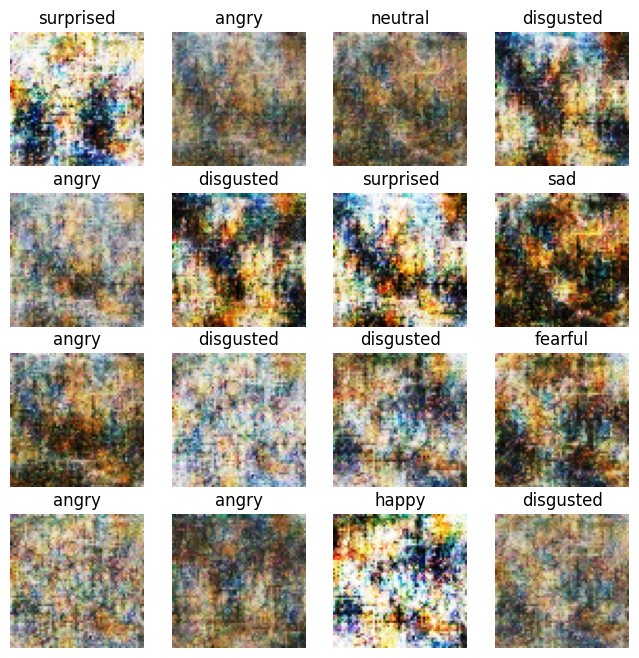

In [78]:
vis_imgs(generator, z_dim=100, n_imgs=16)

In [81]:
#Loading fermodel.keras
model = tf.keras.models.load_model('fermodel.keras')

In [82]:
def preprocess_images(images):
    images_resized = tf.image.resize(images, (48, 48))
    images_resized = images_resized / 255.0
    return images_resized

In [83]:
def predict_labels(model, images):
    predictions = model(images)
    predicted_labels = tf.argmax(predictions, axis=1)
    return predicted_labels

In [113]:
def vis_final(gen, model, z_dim=100, n_imgs=4, n_cls=7):
    noise = tf.random.normal([n_imgs, z_dim])
    lbls = tf.random.uniform([n_imgs], minval=0, maxval=n_cls, dtype=tf.int32)
    lbls_one_hot = tf.one_hot(lbls, depth=n_cls)
    imgs = gen([noise, lbls_one_hot], training=False)
    imgs = (imgs + 1) / 2.0
    processed_imgs = preprocess_images(imgs)
    predicted_labels = model.predict(processed_imgs)
    
    plt.figure(figsize=(10, 10))
    for i in range(n_imgs):
        plt.subplot(4, 4, i+1)
        plt.imshow(imgs[i])
        plt.axis('off')
        true_label = emotion_dict[lbls[i].numpy()]
        pred_label = emotion_dict[tf.argmax(predicted_labels[i]).numpy()]
        plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10, verticalalignment='bottom', horizontalalignment='center')
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


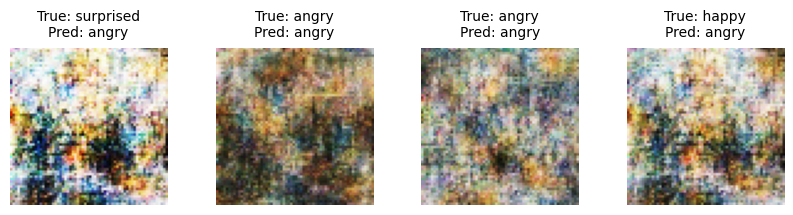

In [114]:
vis_final(generator, model)